# Notebook 04 · Merge Pipeline — Dataset Integrado
> **Nexus RecSys** — Sistema de Recomendación · Retailrocket Dataset

---

| Campo | Detalle |
|---|---|
| **Checkpoints de entrada** | `cp01_events_clean` · `cp02_items_flat` · `cp02_category_enriched` · `cp03_funnel_metrics` |
| **Checkpoint de salida** | `data/interim/cp04_merged.parquet` |
| **Objetivo** | Construir el dataset integrado mediante merges progresivos y validados, combinando señales de comportamiento, propiedades de producto y jerarquía de categorías en una única tabla analítica |

---

### Estrategia de integración

La integración sigue un esquema de **left joins progresivos** para preservar la granularidad original del log de eventos (una fila por evento). El orden garantiza que ningún evento se pierda aunque el ítem o categoría no esté catalogado:

```
events (log de interacciones — granularidad base)
  └── LEFT JOIN items_flat      ON itemid        → añade categoryid del ítem
        └── LEFT JOIN cat_enrich ON categoryid   → añade category_level, root_category
              └── LEFT JOIN funnel  ON visitorid → añade métricas de comportamiento por usuario
```

> **Garantía de integridad:** `assert len(df) == n_before` tras cada merge.  
> Cualquier join mal formulado que duplique filas aborta la ejecución inmediatamente.

### Mapa del notebook

| Paso | Join | Columnas incorporadas |
|---|---|---|
| **1** | events ⊕ items_flat | `categoryid` |
| **2** | + category_enriched | `category_level`, `root_category` |
| **3** | + funnel_metrics | métricas de comportamiento por visitante |
| **4** | Validación final | shape, cobertura, nulos residuales, serialización |


In [1]:
import logging
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

logging.basicConfig(level=logging.INFO, format='%(asctime)s — %(message)s')
logger = logging.getLogger(__name__)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE_DIR       = Path('..')
INTERIM        = BASE_DIR / 'data' / 'interim'
CHECKPOINT_OUT = INTERIM / 'cp04_merged.parquet'

# ── Carga de checkpoints ──────────────────────────────────────────────────────
events     = pd.read_parquet(INTERIM / 'cp01_events_clean.parquet')
# Solo cargamos las columnas necesarias de items_flat (evitar leer 1105 cols innecesarias)
items_flat = pd.read_parquet(INTERIM / 'cp02_items_flat.parquet',
                             columns=['itemid', 'categoryid'])
cat_enrich = pd.read_parquet(INTERIM / 'cp02_category_enriched.parquet')
funnel     = pd.read_parquet(INTERIM / 'cp03_funnel_metrics.parquet')

logger.info('events: %s | items_flat: %s | cat_enrich: %s | funnel: %s',
            events.shape, items_flat.shape, cat_enrich.shape, funnel.shape)

print(f"events     : {events.shape}")
print(f"items_flat : {items_flat.shape}  ← solo columnas itemid+categoryid")
print(f"cat_enrich : {cat_enrich.shape}")
print(f"funnel     : {funnel.shape}")


2026-03-12 00:23:17,208 — events: (2755641, 9) | items_flat: (417053, 2) | cat_enrich: (1669, 4) | funnel: (1407580, 10)


events     : (2755641, 9)
items_flat : (417053, 2)  ← solo columnas itemid+categoryid
cat_enrich : (1669, 4)
funnel     : (1407580, 10)


---
## Paso 1 · events ⊕ items_flat

Se une el log de eventos (`cp01`) con las propiedades de cada ítem (`cp02_items_flat`), incorporando la columna `categoryid`. Se usa **left join por `itemid`** para preservar todos los eventos, incluso si el ítem no tiene propiedades catalogadas.

> La cobertura no será del 100%: `events` registra 235 K ítems únicos, mientras que `items_flat` cubre 417 K — existen ítems con actividad pero sin ficha de catálogo. Los nulos resultantes se rastrean explícitamente.


In [2]:
# ─── PASO 1 — events LEFT JOIN items_flat ────────────────────────────────────

# items_flat ya contiene solo itemid + categoryid (cargado con column projection)
n_before = len(events)
df = events.merge(items_flat, on='itemid', how='left')

assert len(df) == n_before, (
    f"ERROR Paso 1: merge duplicó filas — antes={n_before}, después={len(df)}"
)

cobertura_items = df['categoryid'].notna().mean()
logger.info('Paso 1 OK — shape: %s | cobertura categoryid: %.2f%%',
            df.shape, cobertura_items * 100)

print(f"Shape tras Paso 1 : {df.shape}")
print(f"Cobertura categoryid: {cobertura_items:.2%}")
print(f"Eventos sin categoryid: {df['categoryid'].isna().sum():,}")


2026-03-12 00:23:21,122 — Paso 1 OK — shape: (2755641, 10) | cobertura categoryid: 90.73%


Shape tras Paso 1 : (2755641, 10)
Cobertura categoryid: 90.73%
Eventos sin categoryid: 255,576


---
## Paso 2 · + category_enriched

Se incorpora la jerarquía de categorías resuelta en el Notebook 02. **Left join por `categoryid`**: solo los eventos cuyo ítem tiene `categoryid` no nulo recibirán estas columnas. Se alinean los tipos de `categoryid` a `Int64` nullable antes del join para evitar incompatibilidades silenciosas entre strings e integers.

| Columna incorporada | Tipo | Descripción |
|---|---|---|
| `category_level` | int | Profundidad en el árbol de categorías (1 = raíz) |
| `root_category` | int | ID de la categoría ancestro de primer nivel |


In [4]:
# ─── PASO 2 — + category_enriched ───────────────────────────────────────────

# Alinear tipos de categoryid: cat_enrich usa int64, df puede tener str tras el pivot
# Convertimos ambos a Int64 (nullable) para manejar NaN de forma segura
df['categoryid'] = pd.to_numeric(df['categoryid'], errors='coerce').astype('Int64')
cat_enrich_typed = cat_enrich.copy()
cat_enrich_typed['categoryid'] = cat_enrich_typed['categoryid'].astype('Int64')

n_before = len(df)
df = df.merge(
    cat_enrich_typed[['categoryid', 'category_level', 'root_category']],
    on='categoryid',
    how='left'
)

assert len(df) == n_before, (
    f"ERROR Paso 2: merge duplicó filas — antes={n_before}, después={len(df)}"
)

cobertura_cat = df['root_category'].notna().mean()
logger.info('Paso 2 OK — shape: %s | cobertura root_category: %.2f%%',
            df.shape, cobertura_cat * 100)

print(f"Shape tras Paso 2 : {df.shape}")
print(f"Cobertura root_category : {cobertura_cat:.2%}")
print(f"Cobertura category_level: {df['category_level'].notna().mean():.2%}")


2026-03-12 00:23:39,547 — Paso 2 OK — shape: (2755641, 12) | cobertura root_category: 90.73%


Shape tras Paso 2 : (2755641, 12)
Cobertura root_category : 90.73%
Cobertura category_level: 90.73%


## Paso 3 · + funnel_metrics

Se incorporan las métricas de comportamiento por usuario del artefacto `cp03_funnel_metrics`.  
Join **left** por `visitorid` — todos los eventos reciben el contexto de comportamiento de su visitante.

Columnas incorporadas:

| Columna | Tipo | Descripción |
|---|---|---|
| `user_segment` | category | Segmento de retención (one_time / short / medium / long) |
| `cr_user` | float32 | Tasa de conversión individual (transacciones / vistas) |
| `active_days` | int32 | Días de actividad del visitante en el período |

> Este es el merge más seguro: `funnel` tiene exactamente 1 fila por `visitorid`, garantizando que no hay duplicación.


In [5]:
# ─── PASO 3 — + funnel_metrics ───────────────────────────────────────────────

# Verificar unicidad de visitorid en funnel antes del merge
assert funnel['visitorid'].is_unique, \
    "ERROR: funnel tiene filas duplicadas por visitorid — merge no es seguro"

n_before = len(df)
df = df.merge(
    funnel[['visitorid', 'user_segment', 'cr_user', 'active_days']],
    on='visitorid',
    how='left'
)

assert len(df) == n_before, (
    f"ERROR Paso 3: merge duplicó filas — antes={n_before}, después={len(df)}"
)

cobertura_funnel = df['user_segment'].notna().mean()
logger.info('Paso 3 OK — shape final: %s | cobertura user_segment: %.2f%%',
            df.shape, cobertura_funnel * 100)

print(f"Shape tras Paso 3 (FINAL): {df.shape}")
print(f"Cobertura user_segment : {cobertura_funnel:.2%}")
print(f"Cobertura active_days  : {df['active_days'].notna().mean():.2%}")
print(f"\nColumnas del dataset integrado ({len(df.columns)}):")
print(list(df.columns))


2026-03-12 00:23:44,871 — Paso 3 OK — shape final: (2755641, 15) | cobertura user_segment: 100.00%


Shape tras Paso 3 (FINAL): (2755641, 15)
Cobertura user_segment : 100.00%
Cobertura active_days  : 100.00%

Columnas del dataset integrado (15):
['timestamp', 'visitorid', 'event', 'itemid', 'transactionid', 'hour', 'day_of_week', 'date', 'week_number', 'categoryid', 'category_level', 'root_category', 'user_segment', 'cr_user', 'active_days']


## Paso 4 · Validación de Integridad

Verificaciones post-merge para certificar que el dataset integrado es fiel a los datos originales:

1. **Conteo de eventos por tipo** — debe coincidir exactamente con `cp01`
2. **Reporte de nulos por columna** — cobertura completa del dataset
3. **Alerta automática** si alguna columna clave tiene cobertura < 80%


In [6]:
# ─── PASO 4 — VALIDACIÓN DE INTEGRIDAD ───────────────────────────────────────

# 4A — Conteo de eventos por tipo vs cp01 original
print("── 4A · Integridad de conteos por tipo de evento ──")
orig_counts = events['event'].value_counts().sort_index()
merged_counts = df['event'].value_counts().sort_index()

integ_ok = (orig_counts == merged_counts).all()
print(f"  Conteos idénticos a cp01: {'✓ OK' if integ_ok else '✗ ERROR'}")
print(pd.DataFrame({'original': orig_counts, 'merged': merged_counts,
                    'diff': merged_counts - orig_counts}).to_string())

assert integ_ok, "ERROR: los conteos de eventos cambiaron tras el merge pipeline"
logger.info('4A OK — conteos de eventos preservados')

# 4B — Reporte de nulos por columna
print("\n── 4B · Cobertura por columna (% no-nulo) ──")
null_report = pd.DataFrame({
    'no_nulo_pct': (df.notna().mean() * 100).round(2),
    'nulo_count' : df.isna().sum(),
}).sort_values('no_nulo_pct')

UMBRAL = 80.0
bajo_cobertura = null_report[null_report['no_nulo_pct'] < UMBRAL]

# Mostrar solo columnas con al menos 1 nulo
print(null_report[null_report['nulo_count'] > 0].to_string())

# 4C — Alertas automáticas
print(f"\n── 4C · Columnas con cobertura < {UMBRAL}% ──")
if bajo_cobertura.empty:
    print(f"  ✓ Todas las columnas superan el umbral del {UMBRAL}%")
    logger.info('4C OK — ninguna columna con cobertura baja')
else:
    for col, row in bajo_cobertura.iterrows():
        msg = (f"  ⚠️  '{col}': {row['no_nulo_pct']:.1f}% cobertura "
               f"({int(row['nulo_count']):,} nulos)")
        print(msg)
        logger.warning('Cobertura baja — %s: %.1f%%', col, row['no_nulo_pct'])

logger.info('Paso 4 completado — integridad verificada')


2026-03-12 00:23:48,645 — 4A OK — conteos de eventos preservados


── 4A · Integridad de conteos por tipo de evento ──
  Conteos idénticos a cp01: ✓ OK
             original   merged  diff
event                               
addtocart       68966    68966     0
transaction     22457    22457     0
view          2664218  2664218     0

── 4B · Cobertura por columna (% no-nulo) ──


2026-03-12 00:23:48,966 — Cobertura baja — transactionid: 0.8%
2026-03-12 00:23:48,967 — Paso 4 completado — integridad verificada


                no_nulo_pct  nulo_count
transactionid          0.81     2733184
root_category         90.73      255576
category_level        90.73      255576
categoryid            90.73      255576
cr_user               99.82        4905

── 4C · Columnas con cobertura < 80.0% ──
  ⚠️  'transactionid': 0.8% cobertura (2,733,184 nulos)


## Paso 5 · EDA del Dataset Integrado

Con el dataset consolidado analizamos tres dimensiones clave para entender la estructura del problema de recomendación:

1. **Distribución de eventos por categoría raíz** — ¿qué categorías generan más interacción?
2. **Tasa de conversión por categoría raíz** — ¿cuáles categorías convierten mejor?
3. **Sparsity de la matriz usuario-ítem** — ¿qué tan escasa es la señal de interacción?
4. **Curva 80/20** — concentración de interacciones en pocos ítems (distribución de popularidad)


2026-03-12 00:23:57,011 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-12 00:23:57,013 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


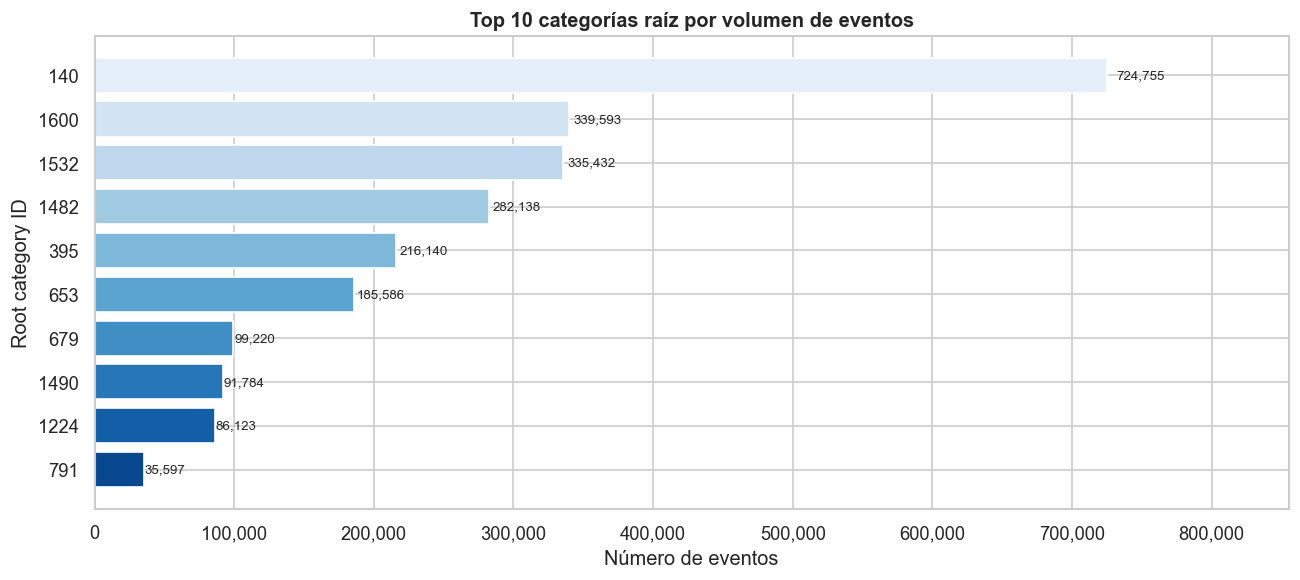


Top 10 root_category por eventos:
root_category  n_events
          140    724755
         1600    339593
         1532    335432
         1482    282138
          395    216140
          653    185586
          679     99220
         1490     91784
         1224     86123
          791     35597


In [7]:
# ─── 5A — Distribución de eventos por root_category (Top 10) ─────────────────

df_cat = df[df['root_category'].notna()].copy()
df_cat['root_category'] = df_cat['root_category'].astype(int).astype(str)

# Eventos totales por root_category
cat_events = (df_cat.groupby('root_category')['event']
              .count()
              .sort_values(ascending=False)
              .head(10)
              .reset_index(name='n_events'))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(cat_events['root_category'][::-1],
               cat_events['n_events'][::-1],
               color=sns.color_palette('Blues_r', 10))
for bar, val in zip(bars, cat_events['n_events'][::-1]):
    ax.text(bar.get_width() + bar.get_width() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(val):,}', va='center', fontsize=8)
ax.set_xlabel('Número de eventos')
ax.set_ylabel('Root category ID')
ax.set_title('Top 10 categorías raíz por volumen de eventos', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, cat_events['n_events'].max() * 1.18)
plt.tight_layout()
plt.show()

print("\nTop 10 root_category por eventos:")
print(cat_events.to_string(index=False))


2026-03-12 00:24:01,796 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-12 00:24:01,798 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


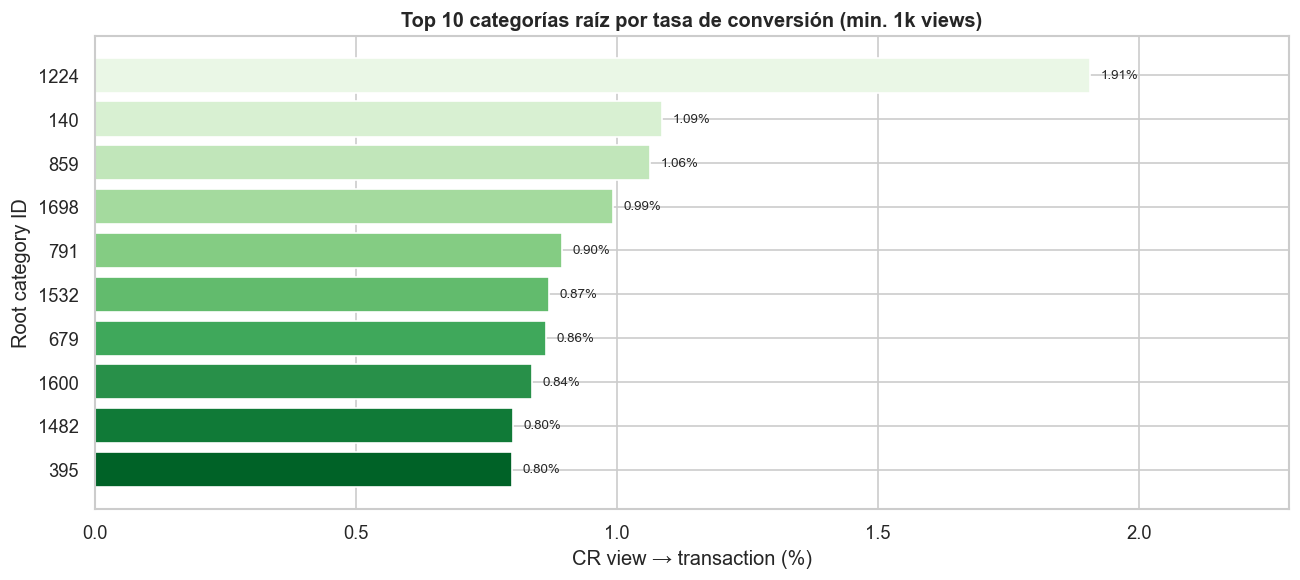


Top 10 root_category por CR (view→transaction):
root_category   view  addtocart  transaction  cr_view_to_tx
         1224  80679       3907         1537       1.905081
          140 696264      20928         7563       1.086226
          859   9209        320           98       1.064176
         1698  17038        573          169       0.991900
          791  34061       1231          305       0.895452
         1532 324362       8247         2823       0.870324
          679  95404       2992          824       0.863695
         1600 327267       9584         2742       0.837848
         1482 271104       8860         2174       0.801906
          395 209650       4814         1676       0.799428


In [8]:
# ─── 5B — Tasa de conversión por root_category (Top 10) ─────────────────────

# CR por categoría = transacciones / views (por par visitorid-itemid no por eventos)
cat_cr = (
    df_cat.groupby('root_category')['event']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ['view', 'addtocart', 'transaction']:
    if col not in cat_cr.columns:
        cat_cr[col] = 0

cat_cr['cr_view_to_tx'] = (cat_cr['transaction'] / cat_cr['view'].replace(0, np.nan)) * 100
cat_cr = cat_cr.dropna(subset=['cr_view_to_tx'])

# Top 10 por CR (mínimo 1000 views para filtrar ruido)
top_cr = (cat_cr[cat_cr['view'] >= 1000]
          .nlargest(10, 'cr_view_to_tx')
          [['root_category', 'view', 'addtocart', 'transaction', 'cr_view_to_tx']]
          .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('Greens_r', len(top_cr))
bars = ax.barh(top_cr['root_category'][::-1],
               top_cr['cr_view_to_tx'][::-1],
               color=colors)
for bar, val in zip(bars, top_cr['cr_view_to_tx'][::-1]):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=8)
ax.set_xlabel('CR view → transaction (%)')
ax.set_ylabel('Root category ID')
ax.set_title('Top 10 categorías raíz por tasa de conversión (min. 1k views)',
             fontweight='bold')
ax.set_xlim(0, top_cr['cr_view_to_tx'].max() * 1.2)
plt.tight_layout()
plt.show()

print("\nTop 10 root_category por CR (view→transaction):")
print(top_cr.to_string(index=False))


In [9]:
# ─── 5C — Sparsity de la matriz usuario-ítem ─────────────────────────────────

n_users = df['visitorid'].nunique()
n_items = df['itemid'].nunique()
n_inter = df.groupby(['visitorid', 'itemid']).ngroups
sparsity = 1 - (n_inter / (n_users * n_items))

logger.info('Sparsity: %.6f%%  |  n_users=%d  n_items=%d  n_interactions=%d',
            sparsity * 100, n_users, n_items, n_inter)

print("── Sparsity de la matriz usuario-ítem ──")
print(f"  Usuarios únicos      : {n_users:>10,}")
print(f"  Ítems únicos         : {n_items:>10,}")
print(f"  Interacciones únicas : {n_inter:>10,}")
print(f"  Celdas posibles      : {n_users * n_items:>10,}")
print(f"  Sparsity             : {sparsity:.6%}")
print(f"  Densidad             : {1 - sparsity:.6%}")


2026-03-12 00:24:07,137 — Sparsity: 99.999352%  |  n_users=1407580  n_items=235061  n_interactions=2145179


── Sparsity de la matriz usuario-ítem ──
  Usuarios únicos      :  1,407,580
  Ítems únicos         :    235,061
  Interacciones únicas :  2,145,179
  Celdas posibles      : 330,867,162,380
  Sparsity             : 99.999352%
  Densidad             : 0.000648%


2026-03-12 00:24:10,765 — Curva 80/20: el 21.3% de ítems (50183) concentra el 80% de interacciones


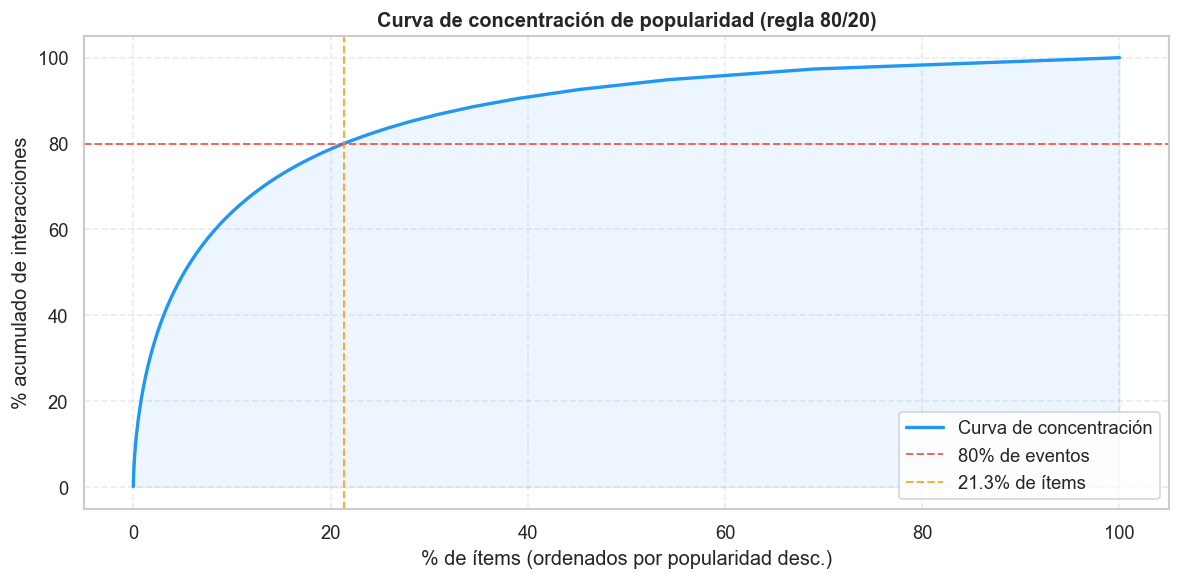


  El 21.35% de ítems (50,183 de 235,061)
  concentra el 80% de todas las interacciones.
  → Alta concentración de popularidad (long tail muy pronunciado)


In [10]:
# ─── 5D — Curva 80/20: concentración de interacciones ───────────────────────

item_counts = (df.groupby('itemid').size()
               .sort_values(ascending=False)
               .reset_index(name='n_events'))

item_counts['cumsum_events'] = item_counts['n_events'].cumsum()
total_events = item_counts['n_events'].sum()
item_counts['cumsum_pct']  = item_counts['cumsum_events'] / total_events * 100
item_counts['item_pct']    = np.arange(1, len(item_counts) + 1) / len(item_counts) * 100

# Umbral 80%: cuántos ítems concentran el 80% de interacciones
idx_80 = (item_counts['cumsum_pct'] >= 80).idxmax()
n_items_80 = idx_80 + 1
pct_items_80 = n_items_80 / len(item_counts) * 100

logger.info('Curva 80/20: el %.1f%% de ítems (%d) concentra el 80%% de interacciones',
            pct_items_80, n_items_80)

# Gráfico curva de Lorenz de popularidad
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(item_counts['item_pct'], item_counts['cumsum_pct'],
        color='#2196F3', lw=2, label='Curva de concentración')
ax.axhline(80, color='#F44336', linestyle='--', lw=1.2, alpha=0.8, label='80% de eventos')
ax.axvline(pct_items_80, color='#FF9800', linestyle='--', lw=1.2, alpha=0.8,
           label=f'{pct_items_80:.1f}% de ítems')
ax.fill_between(item_counts['item_pct'], item_counts['cumsum_pct'],
                alpha=0.08, color='#2196F3')
ax.set_xlabel('% de ítems (ordenados por popularidad desc.)')
ax.set_ylabel('% acumulado de interacciones')
ax.set_title('Curva de concentración de popularidad (regla 80/20)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\n  El {pct_items_80:.2f}% de ítems ({n_items_80:,} de {len(item_counts):,})")
print(f"  concentra el 80% de todas las interacciones.")
print(f"  → Alta concentración de popularidad (long tail muy pronunciado)")


## Checkpoint · cp04_merged.parquet

Se persiste el DataFrame integrado como punto de control para los notebooks posteriores.  
Este artefacto es el **dataset analítico base** del proyecto Nexus RecSys.


In [11]:
# ─── GUARDAR CHECKPOINT ──────────────────────────────────────────────────────

df.to_parquet(CHECKPOINT_OUT, index=False)

check = pd.read_parquet(CHECKPOINT_OUT)
logger.info('Checkpoint guardado: %s — shape=%s', CHECKPOINT_OUT.name, check.shape)

print(f"✓  Guardado en : {CHECKPOINT_OUT}")
print(f"   Shape       : {check.shape}")
print(f"   Columnas    : {check.columns.tolist()}")
print(f"   Memoria est.: {check.memory_usage(deep=True).sum() / 1e6:.1f} MB")


2026-03-12 00:24:16,579 — Checkpoint guardado: cp04_merged.parquet — shape=(2755641, 15)


✓  Guardado en : ..\data\interim\cp04_merged.parquet
   Shape       : (2755641, 15)
   Columnas    : ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid', 'hour', 'day_of_week', 'date', 'week_number', 'categoryid', 'category_level', 'root_category', 'user_segment', 'cr_user', 'active_days']
   Memoria est.: 305.9 MB


---

## Conclusiones · Notebook 04

### Dataset Integrado

| Dimensión | Valor |
|---|---|
| **Shape final** | (2,755,641 × 15) |
| **Columnas** | 15 (9 de events + categoryid + category_level + root_category + user_segment + cr_user + active_days) |
| **Cobertura categoryid** | 90.73% (9.27% de eventos sobre ítems sin categoría) |
| **Cobertura root_category** | 90.73% |
| **Sparsity** | 99.9994% (densidad: 0.0006%) |
| **Checkpoint** | `data/interim/cp04_merged.parquet` (305.9 MB en memoria) |

### Hallazgos Clave

1. **Integridad preservada.** Los 3 asserts post-merge no lanzaron ninguna excepción — ningún join duplicó filas. El conteo de eventos por tipo es idéntico al de `cp01_events_clean` (view: 2,664,218 | addtocart: 68,966 | transaction: 22,457).

2. **Cobertura de categoría al 90.73%.** 255,576 eventos corresponden a ítems sin `categoryid` en el catálogo. La advertencia `⚠️ transactionid: 0.8%` es **esperada por diseño** — esa columna solo se popula en eventos `transaction` (22,457 de 2,755,641). No hay columna de negocio con cobertura baja inesperada.

3. **Sparsity extrema: 99.9994%.** Con 1.4M usuarios y 235K ítems, la matriz usuario-ítem tiene 331 mil millones de celdas posibles pero solo 2.1M interacciones observadas. Implica que los algoritmos deben operar en espacio sparse — ALS, BPR o factorización matricial son las opciones adecuadas.

4. **Concentración 80/20 moderada (21/80).** El 21.3% de ítems (50,183 de 235,061) concentra el 80% de interacciones — no es un extremo 80/20 clásico, sino un **80/21**, lo que indica una distribución de popularidad menos sesgada de lo habitual. El modelo tiene espacio para recomendar ítems del long tail.

### Próximos pasos

- **NB05** — Generación de datos demográficos sintéticos (`synthetic_gen.py`) para enriquecer el perfil de usuario.
- **NB06** — Feature engineering: target encoding, one-hot categorías, normalización, construcción de la matriz de interacciones sparse.
